#### Making Plots for Powerpoint with Kydd

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import shapely as sp
import xarray as xr
from functions.funcs import *
from matplotlib import cm

In [2]:
ds = xr.open_dataset(r"Data\cmems(3).nc")
data = gpd.read_file(r"Data\Palmyra Data\MI_and_SAT_FAD_positions")
Palmyra_shape = gpd.read_file(r"Data\Palmyra_Shapefiles", layer= "PAL_eez") ## two layers in this shape file
NWR = gpd.read_file(r"Data\Palmyra_Shapefiles", layer = 'PAL_KING_NWR_12nm') ## two layers in this shape file


In [30]:
NWR

,mrgid,geoname,pol_type,mrgid_ter1,territory1,mrgid_sov1,sovereign1,iso_ter1,x_1,y_1,mrgid_eez,area_km2,iso_sov1,un_sov1,un_ter1,geometry
0,49158,United States 12 NM (Palmyra Atoll),12NM,8669,Palmyra Atoll,2204,United States,UMI,-162.22355,6.14384,8443,3935,USA,840.0,581.0,"MULTIPOLYGON (((-161.83961 5.89638, -161.83932..."


In [3]:
bath = xr.open_dataset(r"Data\bath.nc")

In [4]:
def Add_bathymetry(fig,ax):
    from matplotlib import cm
    bath = xr.open_dataset(r"Data\bath.nc")
    bath_cmap = cm.get_cmap("Blues_r").copy()
    bath_cmap.set_over('green')
    negative_levels = np.linspace(-10000, 0, 11)
    cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"], 
                    linestyle = "-", cmap = bath_cmap, alpha = 0.8, levels = negative_levels, extend = "max")
    cbr = fig.colorbar(cbr)
    cbr.set_label("Depth (m) ")
    return fig, ax

In [5]:
data = distance_from_Palymra(data)
data2 = gpd.GeoDataFrame()
Collision = data.query("distance_km < 5")

ids = [445848.0, 439111.0, 420777.0, 397314.0]
for id in ids: 
    dFAD = Collision.query(f"Name_ID == {id}")
    data2 = gpd.GeoDataFrame( pd.concat( [data2,dFAD], ignore_index=True) )
print(data2.shape)

(4, 19)


In [ ]:
def Palmyra_plot(ax):
    """"Plots Palmyra onto the graph Returns as """
    Palmyra = Palmyra_obj()
    ax.scatter(Palmyra.x,Palmyra.y, marker  = "o", color = "darkgreen", label = "Palmyra", s =10)
    return ax 

In [26]:
def Kingman_obj():
    """Returns cords of Palymra as a point"""
    import shapely as shp
    return shp.points(-162.078333, 5.883611,)

In [27]:
def Kingmon_plt(ax):
    kingman = Kingman_obj()
    ax.scatter(kingman.x,kingman.y, marker  = "o", color = "darkgreen", label = "Kingman Reef", s =10)
    return ax

In [78]:
def NWR_exteriors(data):
    """Returns the exteriors only from NWP dataset."""
    from shapely.ops import unary_union
    geo = data["geometry"][0]
    geomentry = []

    for polygon in geo.geoms:
        exterior = polygon.exterior
        geomentry.append(sp.Polygon(exterior))
        interior_holes = []
        for interior in polygon.interiors:
            interior_holes.append(sp.Polygon(interior))
        combined_holes = unary_union(interior_holes)
        geomentry.append(combined_holes)
        #multipolygon = sp.MultiPolygon(exteriors)
    labels = ["Palmyra NWR", np.nan,"Kingman NWR", np.nan]
    gpddata = gpd.GeoDataFrame({"labels":labels, "geometry": geomentry})
    return gpddata

In [79]:
def plot_NWPs(ax,data):
    """Plots Palymra and Kingmon Reef, Pass in Shape file as data"""
    NWR_ext = NWR_exteriors(data)
    NWR_ext.plot(ax= ax, edgecolor= "darkgreen",alpha = 0.35, column= "labels", legend= True, categorical=True)
    return ax 

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_1444\2016285204.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bath_cmap = cm.get_cmap("Blues_r").copy()
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_1444\2016285204.py:7: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"],


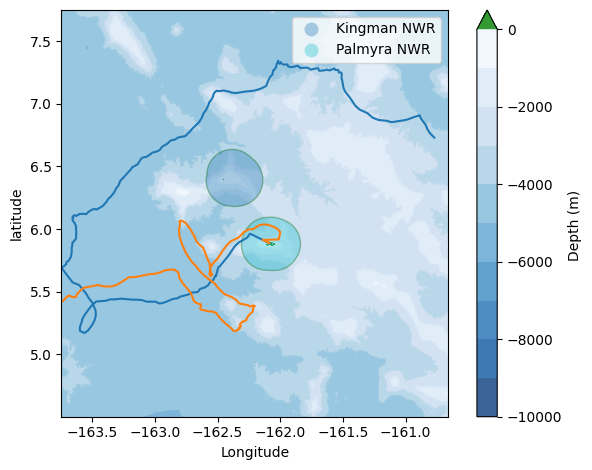

In [111]:
#data2 = data2.reset_index()
fig, ax = plt.subplots()
for i in range(len(data2)-2):
    ax = OneTrajectory(ax, data2,i)

fig, ax = Add_bathymetry(fig, ax)
ax.set_aspect("equal")
ax = plot_NWPs(ax,NWR)
fig.tight_layout()
fig.savefig(r"..\Figures\Collision\Powerpoint.png")
    

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_1444\2016285204.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bath_cmap = cm.get_cmap("Blues_r").copy()
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_1444\2016285204.py:7: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"],


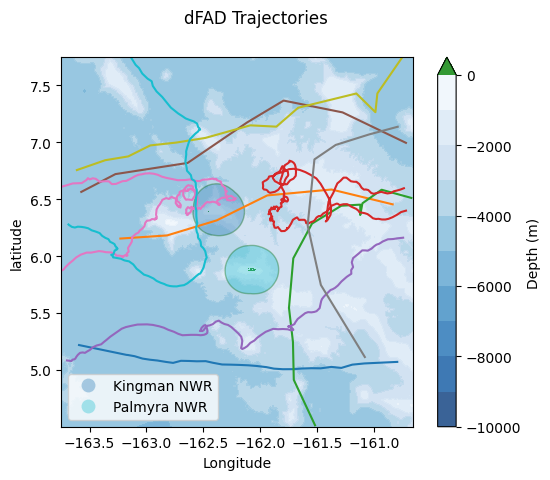

In [110]:

fig, ax = RandTrajectories(data, 10)
fig, ax= Add_bathymetry(fig, ax)
fig.suptitle("dFAD Trajectories")
ax = plot_NWPs(ax,NWR)
fig.savefig(r"..\Figures\Collision\Powerpoint2.png")